<a href="https://colab.research.google.com/github/kushagragoyal300805/Applied-Machine-Learning-Lab_Experiments/blob/main/exp11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [15]:
# ==========================================
# 2. LOAD DATA
# ==========================================
train_df = pd.read_csv("train_features.csv")
val_df   = pd.read_csv("val_features.csv")
test_df  = pd.read_csv("test_features.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (5216, 31)
Validation: (16, 31)
Test: (624, 31)


In [16]:
# ==========================================
# 3. CLEAN DATA
# ==========================================
train_df.columns = train_df.columns.str.strip()
val_df.columns   = val_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

print("\nColumns:\n", train_df.columns)

# Remove image/file column
for col in train_df.columns:
    sample = str(train_df[col].iloc[0]).lower()
    if "jpeg" in sample or "png" in sample or "jpg" in sample:
        print("Dropping:", col)
        train_df.drop(columns=[col], inplace=True)
        val_df.drop(columns=[col], inplace=True)
        test_df.drop(columns=[col], inplace=True)


Columns:
 Index(['mean', 'std', 'min', 'max', 'median', 'p10', 'p90', 'skewness',
       'kurtosis', 'entropy', 'glcm_contrast', 'glcm_energy',
       'glcm_homogeneity', 'glcm_correlation', 'edge_density', 'edge_count',
       'edge_strength', 'fft_mean', 'fft_std', 'fft_energy', 'lbp_0', 'lbp_1',
       'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7', 'lbp_8', 'lbp_9',
       'image'],
      dtype='object')
Dropping: image


In [17]:
# ==========================================
# 4. DEFINE TARGET
# ==========================================
target_column = train_df.columns[-1]   # label usually last column
print("Target Column:", target_column)

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_val = val_df.drop(columns=[target_column])
y_val = val_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

Target Column: lbp_9


In [18]:

# ==========================================
# 5. FIX TARGET (CLASS LABELS)
# ==========================================
def fix_labels(y):
    if y.dtype != 'object':
        return (y > y.median()).astype(int)
    return y

y_train = fix_labels(y_train)
y_val   = fix_labels(y_val)
y_test  = fix_labels(y_test)

# Encode if categorical
if y_train.dtype == 'object':
    le = LabelEncoder()
    le.fit(pd.concat([y_train, y_val, y_test]))
    y_train = le.transform(y_train)
    y_val   = le.transform(y_val)
    y_test  = le.transform(y_test)

print("Classes:", np.unique(y_train))


Classes: [0 1]


In [19]:
# ==========================================
# 6. HANDLE MISSING VALUES
# ==========================================
X_train = X_train.fillna(X_train.mean())
X_val   = X_val.fillna(X_val.mean())
X_test  = X_test.fillna(X_test.mean())



Statistical Summary:
               mean          std          min          max       median  \
count  5216.000000  5216.000000  5216.000000  5216.000000  5216.000000   
mean      0.481919     0.222822     0.002022     0.987354     0.522075   
std       0.072694     0.037348     0.013414     0.048650     0.092902   
min       0.237626     0.079597     0.000000     0.596078     0.223529   
25%       0.438359     0.197766     0.000000     1.000000     0.470588   
50%       0.481361     0.224454     0.000000     1.000000     0.525490   
75%       0.526967     0.249546     0.000000     1.000000     0.580392   
max       0.868507     0.342862     0.301961     1.000000     0.886275   

               p10          p90     skewness     kurtosis      entropy  ...  \
count  5216.000000  5216.000000  5216.000000  5216.000000  5216.000000  ...   
mean      0.123173     0.738254    -0.570828    -0.485375     7.276571  ...   
std       0.106454     0.071116     0.407459     0.827220     0.229401  .

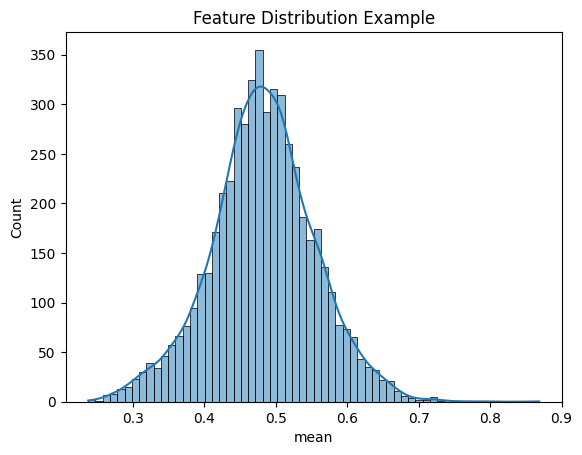

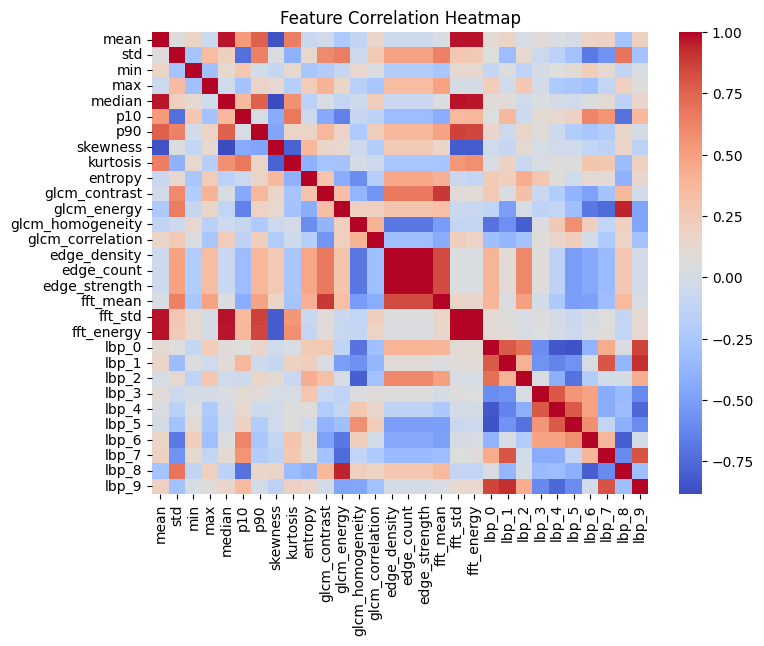

In [20]:
# ==========================================
# 7. EDA (OBJECTIVE 2)
# ==========================================
print("\nStatistical Summary:\n", train_df.describe())

# Feature distribution
plt.figure()
sns.histplot(X_train.iloc[:,0], kde=True)
plt.title("Feature Distribution Example")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(train_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [21]:
# ==========================================
# 8. FEATURE SCALING
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [22]:
# ==========================================
# 9. PCA (OBJECTIVE 5)
# ==========================================
pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)
X_val   = pca.transform(X_val)
X_test  = pca.transform(X_test)

print("Reduced Features:", X_train.shape[1])


Reduced Features: 9


In [23]:
# ==========================================
# 10. MODEL FUNCTION
# ==========================================
def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"\n{name} Performance")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    print("\nClassification Report:\n", classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()

    return acc


Logistic Regression Performance
Accuracy : 0.8894230769230769
Precision: 0.991869918699187
Recall   : 0.7845659163987139
F1 Score : 0.8761220825852782

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90       313
           1       0.99      0.78      0.88       311

    accuracy                           0.89       624
   macro avg       0.91      0.89      0.89       624
weighted avg       0.91      0.89      0.89       624



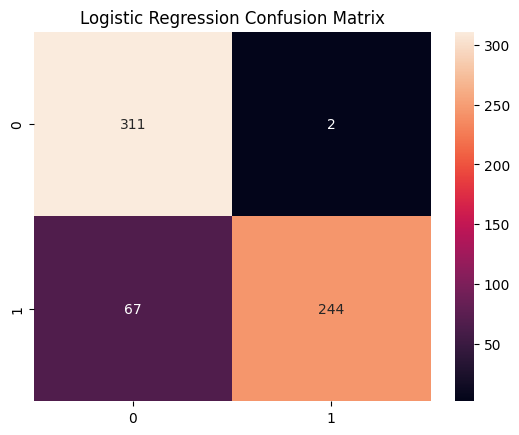


SVM Performance
Accuracy : 0.907051282051282
Precision: 0.996078431372549
Recall   : 0.8167202572347267
F1 Score : 0.8975265017667845

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.91       313
           1       1.00      0.82      0.90       311

    accuracy                           0.91       624
   macro avg       0.92      0.91      0.91       624
weighted avg       0.92      0.91      0.91       624



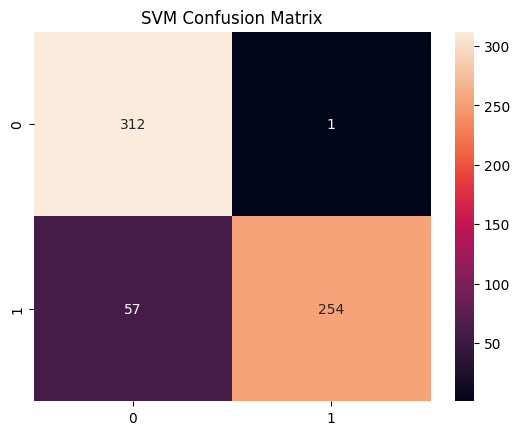


Decision Tree Performance
Accuracy : 0.8717948717948718
Precision: 0.9494163424124513
Recall   : 0.7845659163987139
F1 Score : 0.8591549295774648

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.96      0.88       313
           1       0.95      0.78      0.86       311

    accuracy                           0.87       624
   macro avg       0.88      0.87      0.87       624
weighted avg       0.88      0.87      0.87       624



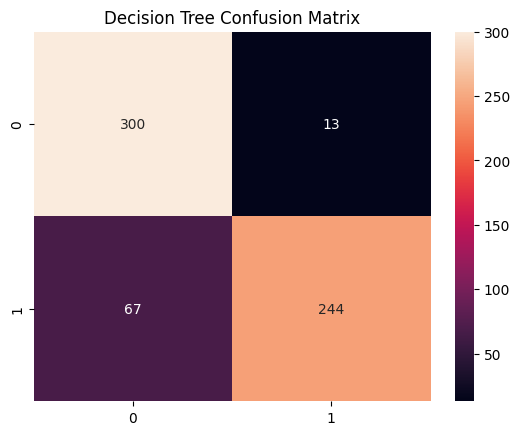


Random Forest Performance
Accuracy : 0.9006410256410257
Precision: 0.973384030418251
Recall   : 0.8231511254019293
F1 Score : 0.89198606271777

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       313
           1       0.97      0.82      0.89       311

    accuracy                           0.90       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.90      0.90       624



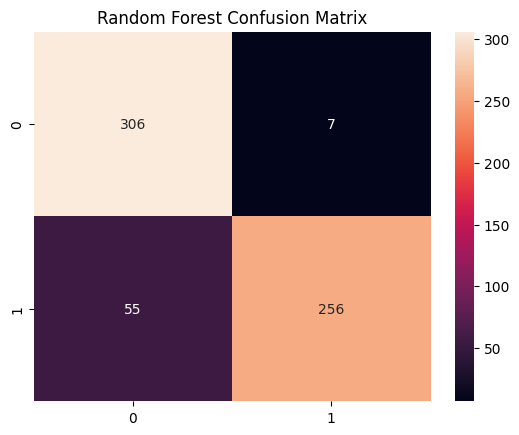


KNN Performance
Accuracy : 0.9006410256410257
Precision: 0.959409594095941
Recall   : 0.8360128617363344
F1 Score : 0.8934707903780069

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91       313
           1       0.96      0.84      0.89       311

    accuracy                           0.90       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.90      0.90       624



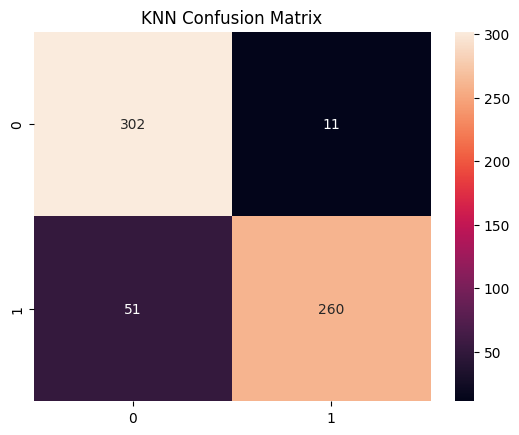

In [24]:
# ==========================================
# 11. TRAIN MODELS (OBJECTIVE 4)
# ==========================================
results = {}

results["Logistic Regression"] = evaluate(LogisticRegression(max_iter=1000), "Logistic Regression")
results["SVM"] = evaluate(SVC(), "SVM")
results["Decision Tree"] = evaluate(DecisionTreeClassifier(), "Decision Tree")
results["Random Forest"] = evaluate(RandomForestClassifier(), "Random Forest")
results["KNN"] = evaluate(KNeighborsClassifier(), "KNN")



Model Comparison:
                  Model  Accuracy
0  Logistic Regression  0.889423
1                  SVM  0.907051
2        Decision Tree  0.871795
3        Random Forest  0.900641
4                  KNN  0.900641


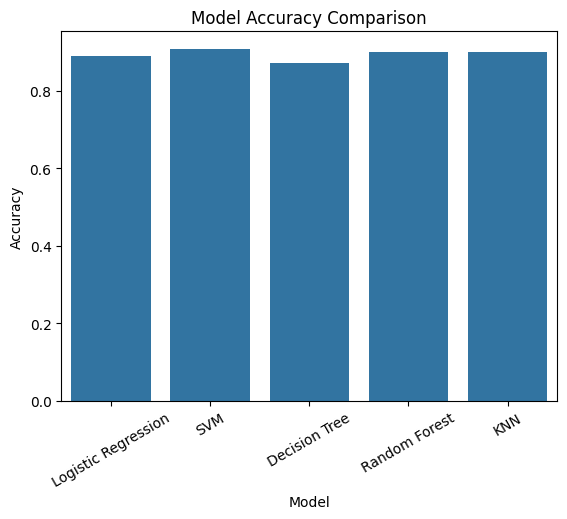

In [25]:
# ==========================================
# 12. MODEL COMPARISON (OBJECTIVE 6)
# ==========================================
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print("\nModel Comparison:\n", results_df)

plt.figure()
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()
